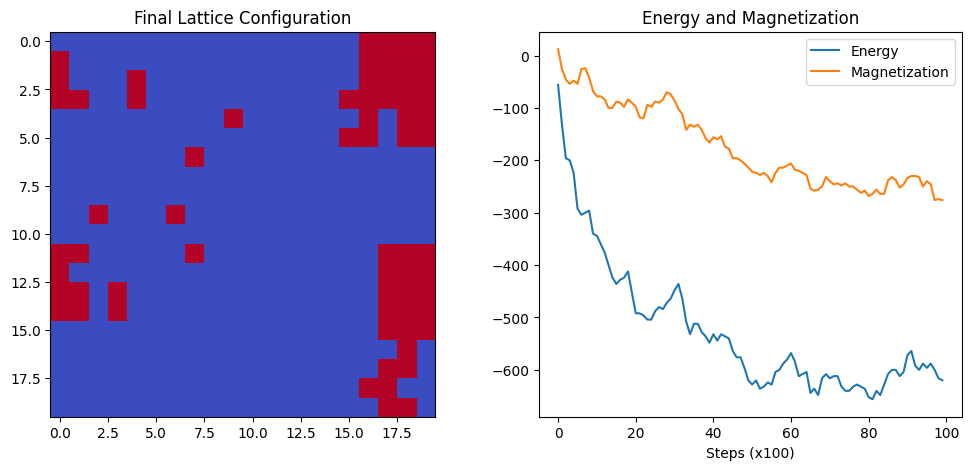

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_lattice(N):
    """Initialize the lattice with random spins."""
    lattice = np.random.choice([-1, 1], size=(N, N))
    return lattice

def calculate_energy(lattice, J=1):
    """Calculate the total energy of the lattice."""
    energy = 0
    N = lattice.shape[0]
    for i in range(N):
        for j in range(N):
            S = lattice[i, j]
            neighbors = lattice[(i+1)%N, j] + lattice[i, (j+1)%N] + lattice[(i-1)%N, j] + lattice[i, (j-1)%N]
            energy += -J * S * neighbors
    return energy / 2  # Each pair counted twice

def calculate_magnetization(lattice):
    """Calculate the total magnetization of the lattice."""
    return np.sum(lattice)

def metropolis_step(lattice, beta):
    """Perform a single Metropolis-Hastings step."""
    N = lattice.shape[0]
    i, j = np.random.randint(0, N, size=2)
    S = lattice[i, j]
    neighbors = lattice[(i+1)%N, j] + lattice[i, (j+1)%N] + lattice[(i-1)%N, j] + lattice[i, (j-1)%N]
    dE = 2 * S * neighbors
    if dE < 0 or np.random.rand() < np.exp(-dE * beta):
        lattice[i, j] *= -1
    return lattice

def simulate_ising(N, T, steps):
    """Simulate the Ising model."""
    lattice = initialize_lattice(N)
    beta = 1.0 / T
    energies = []
    magnetizations = []
    for step in range(steps):
        lattice = metropolis_step(lattice, beta)
        if step % 100 == 0:
            energies.append(calculate_energy(lattice))
            magnetizations.append(calculate_magnetization(lattice))
    return lattice, energies, magnetizations

# Parameters
N = 20  # Lattice size
T = 2.0  # Temperature
steps = 10000  # Number of simulation steps

# Run simulation
lattice, energies, magnetizations = simulate_ising(N, T, steps)

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(lattice, cmap='coolwarm')
plt.title('Final Lattice Configuration')
plt.subplot(1, 2, 2)
plt.plot(energies, label='Energy')
plt.plot(magnetizations, label='Magnetization')
plt.xlabel('Steps (x100)')
plt.legend()
plt.title('Energy and Magnetization')
plt.show()

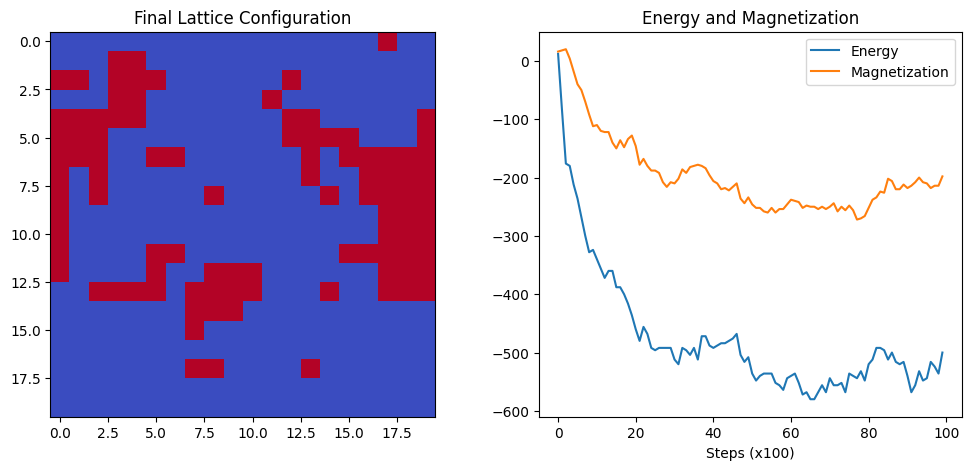

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_lattice(N):
    """Initialize the lattice with random spins."""
    lattice = np.random.choice([-1, 1], size=(N, N))
    return lattice

def calculate_energy(lattice, J=1):
    """Calculate the total energy of the lattice."""
    energy = 0
    N = lattice.shape[0]
    for i in range(N):
        for j in range(N):
            S = lattice[i, j]
            neighbors = lattice[(i+1)%N, j] + lattice[i, (j+1)%N] + lattice[(i-1)%N, j] + lattice[i, (j-1)%N]
            energy += -J * S * neighbors
    return energy / 2  # Each pair counted twice

def calculate_magnetization(lattice):
    """Calculate the total magnetization of the lattice."""
    return np.sum(lattice)

def metropolis_step(lattice, beta, J=1):
    """Perform a single Metropolis-Hastings step."""
    N = lattice.shape[0]
    i, j = np.random.randint(0, N, size=2)
    S = lattice[i, j]
    neighbors = lattice[(i+1)%N, j] + lattice[i, (j+1)%N] + lattice[(i-1)%N, j] + lattice[i, (j-1)%N]
    dE = 2 * J * S * neighbors
    if dE < 0 or np.random.rand() < np.exp(-dE * beta):
        lattice[i, j] *= -1
    return lattice

def simulate_ising(N, T, steps, J=1):
    """Simulate the Ising model."""
    lattice = initialize_lattice(N)
    beta = 1.0 / T
    energies = []
    magnetizations = []
    for step in range(steps):
        lattice = metropolis_step(lattice, beta, J)
        if step % 100 == 0:
            energies.append(calculate_energy(lattice, J))
            magnetizations.append(calculate_magnetization(lattice))
    return lattice, energies, magnetizations

# Parameters
N = 20  # Lattice size
T = 2.0  # Temperature
steps = 10000  # Number of simulation steps
J = 1  # Interaction strength

# Run simulation
lattice, energies, magnetizations = simulate_ising(N, T, steps, J)

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(lattice, cmap='coolwarm')
plt.title('Final Lattice Configuration')
plt.subplot(1, 2, 2)
plt.plot(energies, label='Energy')
plt.plot(magnetizations, label='Magnetization')
plt.xlabel('Steps (x100)')
plt.legend()
plt.title('Energy and Magnetization')
plt.show()